In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn joblib --quiet

In [17]:
import os
import random
import json
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import joblib

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

# Mount Google Drive

In [18]:
from google.colab import drive
drive.mount("/users/")

Drive already mounted at /users/ to attempt to forcibly remount, call drive.mount("/users/", force_remount=True).


# Paths & Dataset Config

In [19]:
BASE = "/users/"

DATASETS = {
    "CIC_IIoT_2025": os.path.join(BASE, "CIC_IIoT_2025"),
    "CIC_BCCC_NRC_IoMT_2024": os.path.join(BASE, "CIC_BCCC_NRC_IoMT_2024"),
    "CSE_CIC_IDS2018": os.path.join(BASE, "CSE_CIC_IDS2018"),
    "FALCON_ID_Combined": os.path.join(BASE, "Combined"),
}

MODELS_DIR = "/users/"
os.makedirs(MODELS_DIR, exist_ok=True)

In [20]:
TARGET_DATASET = "FALCON_ID_Combined"

print("Using dataset for FL:", TARGET_DATASET)
print("Base dir:", DATASETS[TARGET_DATASET])

Using dataset for FL: FALCON_ID_Combined
Base dir: /users/


# Load Central Latent Splits

In [21]:
def load_latent_splits(dataset_name, dataset_dir):
    if dataset_name == "FALCON_ID_Combined":
        X_train = np.load(os.path.join(dataset_dir, "combined_train_latent.npy"))
        X_val   = np.load(os.path.join(dataset_dir, "combined_val_latent.npy"))
        X_test  = np.load(os.path.join(dataset_dir, "combined_test_latent.npy"))

        y_train = np.load(os.path.join(dataset_dir, "combined_y_train.npy"))
        y_val   = np.load(os.path.join(dataset_dir, "combined_y_val.npy"))
        y_test  = np.load(os.path.join(dataset_dir, "combined_y_test.npy"))
    else:
        X_train = np.load(os.path.join(dataset_dir, "train_latent.npy"))
        X_val   = np.load(os.path.join(dataset_dir, "val_latent.npy"))
        X_test  = np.load(os.path.join(dataset_dir, "test_latent.npy"))

        y_train = np.load(os.path.join(dataset_dir, "y_train.npy"))
        y_val   = np.load(os.path.join(dataset_dir, "y_val.npy"))
        y_test  = np.load(os.path.join(dataset_dir, "y_test.npy"))

    return X_train, X_val, X_test, y_train, y_val, y_test


DATASET_DIR = DATASETS[TARGET_DATASET]

X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c = load_latent_splits(
    TARGET_DATASET, DATASET_DIR
)

print("Central splits shapes:")
print("Train:", X_train_c.shape, y_train_c.shape)
print("Val  :", X_val_c.shape,   y_val_c.shape)
print("Test :", X_test_c.shape,  y_test_c.shape)

input_dim   = X_train_c.shape[1]
num_classes = len(np.unique(y_train_c))
print("Input dim:", input_dim, "| Num classes:", num_classes)

Central splits shapes:
Train: (9136746, 64) (9136746,)
Val  : (1957874, 64) (1957874,)
Test : (1957876, 64) (1957876,)
Input dim: 64 | Num classes: 37


# Load Non-IID Client Metadata

In [22]:
def load_client_metadata(dataset_dir):
    meta_path = os.path.join(dataset_dir, "clients_non_iid", "clients_metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path, "r") as f:
            return json.load(f)
    return None

CLIENTS_BASE_DIR = os.path.join(DATASET_DIR, "clients_non_iid")
client_meta = load_client_metadata(DATASET_DIR)

if client_meta is None:
    raise RuntimeError(f"No clients_metadata.json found under {CLIENTS_BASE_DIR}")

n_clients = client_meta["n_clients"]
print(f"Found {n_clients} clients for dataset: {TARGET_DATASET}")

client_ids = [c["client_id"] for c in client_meta["clients"]]
print("Client IDs:", client_ids[:10], "..." if len(client_ids) > 10 else "")

Found 30 clients for dataset: FALCON_ID_Combined
Client IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ...


# Load Data for a Single Client

In [23]:
def load_client_data(dataset_dir, client_id, max_samples=None, shuffle=True):

    client_dir = os.path.join(dataset_dir, "clients_non_iid", f"client_{client_id}")
    X_path = os.path.join(client_dir, "X.npy")
    y_path = os.path.join(client_dir, "y.npy")

    if not (os.path.exists(X_path) and os.path.exists(y_path)):
        raise FileNotFoundError(f"Missing client data for client_{client_id}: {X_path}, {y_path}")

    X = np.load(X_path)
    y = np.load(y_path)

    if shuffle:
        idx = np.arange(len(y))
        np.random.shuffle(idx)
        X = X[idx]
        y = y[idx]

    if (max_samples is not None) and (len(y) > max_samples):
        X = X[:max_samples]
        y = y[:max_samples]

    return X, y


# 🔎 Quick sanity check on one client
sample_cid = client_ids[0]
X_c, y_c = load_client_data(DATASET_DIR, sample_cid, max_samples=5000)
print(f"Client {sample_cid} → X:{X_c.shape}, y:{y_c.shape}, unique labels:{np.unique(y_c)}")

Client 0 → X:(5000, 64), y:(5000,), unique labels:[ 0  1  2  5  7  9 10 12 18 20 22 23 24 25 27 28 31 33 36]


# FALCON-ID Local Model: CNN + BiLSTM + Attention

In [24]:
def build_falcon_id_local_model(input_dim, num_classes, learning_rate=1e-3, l2_reg=1e-4, dropout_rate=0.4):
    inp = layers.Input(shape=(input_dim,), name="latent_input")
    x = layers.Reshape((input_dim, 1))(inp)  # (batch, 64, 1)

    # ---- Residual Block 1 ----
    shortcut = layers.Conv1D(64, 1, padding="same",
                             kernel_regularizer=regularizers.l2(l2_reg))(x)

    x1 = layers.Conv1D(64, 3, padding="same",
                       kernel_regularizer=regularizers.l2(l2_reg))(x)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Activation("relu")(x1)
    x1 = layers.Conv1D(64, 3, padding="same",
                       kernel_regularizer=regularizers.l2(l2_reg))(x1)
    x1 = layers.BatchNormalization()(x1)

    x = layers.Add()([shortcut, x1])
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # ---- Residual Block 2 ----
    shortcut2 = layers.Conv1D(128, 1, padding="same",
                              kernel_regularizer=regularizers.l2(l2_reg))(x)

    x2 = layers.Conv1D(128, 3, padding="same",
                       kernel_regularizer=regularizers.l2(l2_reg))(x)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Activation("relu")(x2)
    x2 = layers.Conv1D(128, 3, padding="same",
                       kernel_regularizer=regularizers.l2(l2_reg))(x2)
    x2 = layers.BatchNormalization()(x2)

    x = layers.Add()([shortcut2, x2])
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.SpatialDropout1D(0.2)(x)

    # ---- BiLSTM ----
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True,
                    kernel_regularizer=regularizers.l2(l2_reg))
    )(x)

    # ---- Additive Attention (Fixed) ----
    score = layers.Dense(128, activation="tanh")(x)
    attn_weights = layers.Dense(1, activation="softmax")(score)

    context = layers.Lambda(lambda z: tf.reduce_sum(z[0] * z[1], axis=1))([x, attn_weights])

    # ---- Classifier ----
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(l2_reg))(context)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(num_classes, activation="softmax", name="logits")(x)

    model = models.Model(inputs=inp, outputs=out, name="FALCON_ID_CNN_BiLSTM_Attn")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    return model


tmp_model = build_falcon_id_local_model(input_dim=input_dim, num_classes=num_classes)
tmp_model.summary()

Model: "FALCON_ID_CNN_BiLSTM_Attn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ latent_input        │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64, 1)     │          0 │ latent_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 64, 64)    │        256 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 64, 64)    │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 64, 64)    │        128 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ conv1d[0][0],     │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 32, 64)    │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 32, 128)   │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 32, 128)   │     49,280 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 32, 128)   │      8,320 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128)   │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 128)   │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 128)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                 

 Total params: 497,766 (1.90 MB)

 Trainable params: 496,230 (1.89 MB)

 Non-trainable params: 1,536 (6.00 KB)

# FedAvg Utilities

In [25]:
def get_model_weights(model):
    return model.get_weights()

def set_model_weights(model, weights):
    model.set_weights(weights)

def fedavg_weighted(client_weights, client_sizes):
    total_samples = np.sum(client_sizes)
    num_layers = len(client_weights[0])
    agg_weights = []

    for layer_idx in range(num_layers):
        layer_sum = np.zeros_like(client_weights[0][layer_idx])
        for cw, n in zip(client_weights, client_sizes):
            layer_sum += (n / total_samples) * cw[layer_idx]
        agg_weights.append(layer_sum)

    return agg_weights

# FL Hyperparameters

In [27]:

FL_CONFIG = {
    "num_rounds": 20,
    "local_epochs": 1,
    "client_fraction": 0.2,
    "batch_size": 2048,
    "max_client_samples": 80000,
    "eval_max_test_samples": 300000,
    "seed": 42,
}

random.seed(FL_CONFIG["seed"])
np.random.seed(FL_CONFIG["seed"])

FL_CONFIG

{'num_rounds': 20,
 'local_epochs': 1,
 'client_fraction': 0.2,
 'batch_size': 2048,
 'max_client_samples': 80000,
 'eval_max_test_samples': 300000,
 'seed': 42}

# Global Test Evaluation Helper

In [28]:
from sklearn.metrics import classification_report

def evaluate_global_model(model, X_test, y_test, max_samples=None, dataset_name=""):
    if max_samples is not None and len(y_test) > max_samples:
        X_test_eval = X_test[:max_samples]
        y_test_eval = y_test[:max_samples]
    else:
        X_test_eval = X_test
        y_test_eval = y_test

    preds = model.predict(X_test_eval, batch_size=4096, verbose=1)
    y_pred = np.argmax(preds, axis=1)

    acc = accuracy_score(y_test_eval, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test_eval, y_pred, average="weighted", zero_division=0
    )

    print(f"\n📊 Global Evaluation — {dataset_name}")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    print("\nDetailed classification report:")
    print(classification_report(y_test_eval, y_pred, digits=4))

    return {
        "accuracy": float(acc),
        "precision_weighted": float(prec),
        "recall_weighted": float(rec),
        "f1_weighted": float(f1),
        "num_samples_eval": int(len(y_test_eval)),
    }

# Federated Training Loop (FedAvg)

In [29]:
def run_federated_training(
    dataset_name,
    dataset_dir,
    client_ids,
    X_test_central,
    y_test_central,
    fl_config,
):
    num_clients = len(client_ids)
    print(f"\n==============================")
    print(f"📡 Federated Training — {dataset_name}")
    print(f"Clients: {num_clients}")
    print(f"Rounds: {fl_config['num_rounds']}, Local epochs: {fl_config['local_epochs']}")
    print(f"Client fraction per round: {fl_config['client_fraction']}")
    print(f"==============================\n")

    # Build initial global model
    global_model = build_falcon_id_local_model(
        input_dim=input_dim,
        num_classes=num_classes,
        learning_rate=1e-3,
        l2_reg=1e-4,
        dropout_rate=0.4,
    )

    # Initial global evaluation (untrained)
    history = []
    print("📏 Initial (untrained) evaluation:")
    init_metrics = evaluate_global_model(
        global_model,
        X_test_central,
        y_test_central,
        max_samples=fl_config["eval_max_test_samples"],
        dataset_name=f"{dataset_name} (Initial)",
    )
    init_metrics["round"] = 0
    history.append(init_metrics)

    for rnd in range(1, fl_config["num_rounds"] + 1):
        print(f"\n==============================")
        print(f"🌐 FL Round {rnd}/{fl_config['num_rounds']}")
        print(f"==============================")

        # Select subset of clients
        m = max(1, int(fl_config["client_fraction"] * num_clients))
        selected_clients = random.sample(client_ids, m)
        print(f"Selected clients: {selected_clients[:10]}{'...' if len(selected_clients)>10 else ''}")

        global_weights = get_model_weights(global_model)

        client_weights = []
        client_sizes = []

        for cid in selected_clients:
            # Load client data
            X_c, y_c = load_client_data(
                dataset_dir,
                cid,
                max_samples=fl_config["max_client_samples"],
                shuffle=True,
            )
            n_c = len(y_c)
            if n_c == 0:
                continue

            print(f"  ▶ Client {cid} — samples: {n_c}")

            # Build client model & set global weights
            client_model = build_falcon_id_local_model(
                input_dim=input_dim,
                num_classes=num_classes,
                learning_rate=1e-3,
                l2_reg=1e-4,
                dropout_rate=0.4,
            )
            set_model_weights(client_model, global_weights)

            # Local training
            client_model.fit(
                X_c,
                y_c,
                epochs=fl_config["local_epochs"],
                batch_size=fl_config["batch_size"],
                verbose=0,
            )

            # Collect updated weights
            client_w = get_model_weights(client_model)
            client_weights.append(client_w)
            client_sizes.append(n_c)

            # Free memory from client model
            tf.keras.backend.clear_session()

        if not client_weights:
            print("No client updates in this round, skipping aggregation.")
            continue

        # FedAvg aggregation
        new_global_weights = fedavg_weighted(client_weights, client_sizes)
        set_model_weights(global_model, new_global_weights)

        # Evaluate global model after this round
        metrics = evaluate_global_model(
            global_model,
            X_test_central,
            y_test_central,
            max_samples=fl_config["eval_max_test_samples"],
            dataset_name=f"{dataset_name} (Round {rnd})",
        )
        metrics["round"] = rnd
        history.append(metrics)

    return global_model, history


# 🏃 Run FL for the chosen dataset
global_fl_model, fl_history = run_federated_training(
    TARGET_DATASET,
    DATASET_DIR,
    client_ids,
    X_test_c,
    y_test_c,
    FL_CONFIG,
)


📡 Federated Training — FALCON_ID_Combined
Clients: 30
Rounds: 20, Local epochs: 1
Client fraction per round: 0.2

📏 Initial (untrained) evaluation:


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (4096, 16, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 16, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step

📊 Global Evaluation — FALCON_ID_Combined (Initial)
Accuracy : 0.002256666666666667
Precision: 1.5687701195286e-05
Recall   : 0.002256666666666667
F1 Score : 2.9675851723167353e-05

Detailed classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       900
           1     0.0000    0.0000    0.0000       901
           2     0.0021    0.6393    0.0043       901
           3     0.0000    0.0000    0.0000       901
           4     0.0000    0.0000    0.0000       901
           5     0.0000    0.0000    0.0000       901
           6     0.0000    0.0000    0.0000       901
           8     0.0000    0.0000    0.0000      2864
          14     0.0000    0.0000    0.0000       218
          15     0.0000    0.0000    0.0000       239
          17     0.0000    0.0000    0.0000       171
          18     0.0000    0.0000    0.0000    182847
          19     0.0067    0.0421    0.0115

...

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 16, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


  ▶ Client 20 — samples: 78934
  ▶ Client 16 — samples: 80000
  ▶ Client 18 — samples: 80000
  ▶ Client 7 — samples: 80000
  ▶ Client 22 — samples: 80000
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

📊 Global Evaluation — FALCON_ID_Combined (Round 19)
Accuracy : 0.9520933333333333
Precision: 0.9479263617155094
Recall   : 0.9520933333333333
F1 Score : 0.9356759525003666

Detailed classification report:
              precision    recall  f1-score   support

           0     0.3888    0.9144    0.5456       900
           1     0.0000    0.0000    0.0000       901
           2     0.4217    0.5738    0.4861       901
           3     0.0000    0.0000    0.0000       901
           4     0.0000    0.0000    0.0000       901
           5     0.3158    0.9012    0.4677       901
           6     0.9951    0.4495    0.6193       901
           8     0.7168    0.7626    0.7390      2864
          13     0.0000    0.0000    0.0000         0
          14     0.0000    0.0000    0.0000       218
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

  ▶ Client 13 — samples: 80000
  ▶ Client 5 — samples: 80000
  ▶ Client 29 — samples: 80000
  ▶ Client 14 — samples: 80000
  ▶ Client 11 — samples: 80000
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

📊 Global Evaluation — FALCON_ID_Combined (Round 20)
Accuracy : 0.9495666666666667
Precision: 0.9223193338994905
Recall   : 0.9495666666666667
F1 Score : 0.9340647545052353

Detailed classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       900
           1     0.4589    0.5949    0.5181       901
           2     0.3154    0.2153    0.2559       901
           3     0.0000    0.0000    0.0000       901
           4     0.5217    0.3208    0.3973       901
           5     0.2906    0.9922    0.4496       901
           6     0.9387    0.9001    0.9190       901
           7     0.0000    0.0000    0.0000         0
           8     0.7330    0.7755    0.7536      2864
          14     0.0000    0.0000    0.0000       218
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# Save Global FL Model & History

In [30]:
model_path = os.path.join(
    MODELS_DIR,
    f"{TARGET_DATASET}_FL_FedAvg_FALCON_ID.keras"
)
history_path = os.path.join(
    MODELS_DIR,
    f"{TARGET_DATASET}_FL_FedAvg_history.json"
)

global_fl_model.save(model_path)
print("✔ Global FL model saved →", model_path)

with open(history_path, "w") as f:
    json.dump(fl_history, f, indent=4)

print("✔ FL training history saved →", history_path)

✔ Global FL model saved → /users/
✔ FL training history saved → /users/


# Plot Accuracy over Rounds

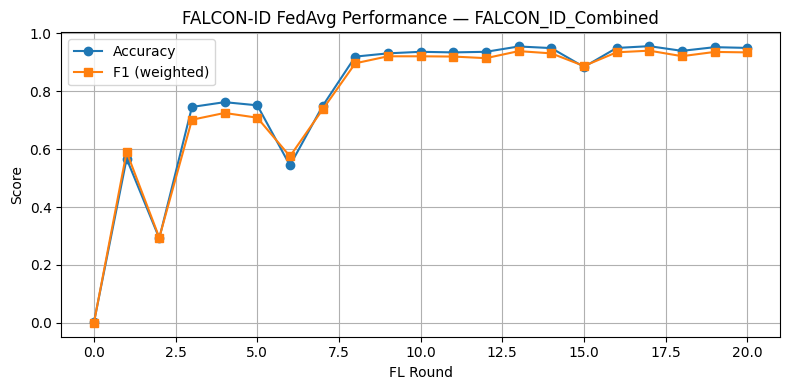

[{'accuracy': 0.002256666666666667,
  'precision_weighted': 1.5687701195286e-05,
  'recall_weighted': 0.002256666666666667,
  'f1_weighted': 2.9675851723167353e-05,
  'num_samples_eval': 300000,
  'round': 0},
 {'accuracy': 0.5670933333333333,
  'precision_weighted': 0.6420823759524803,
  'recall_weighted': 0.5670933333333333,
  'f1_weighted': 0.590288246916393,
  'num_samples_eval': 300000,
  'round': 1},
 {'accuracy': 0.29219666666666666,
  'precision_weighted': 0.640367296722895,
  'recall_weighted': 0.29219666666666666,
  'f1_weighted': 0.2945594924749405,
  'num_samples_eval': 300000,
  'round': 2},
 {'accuracy': 0.74568,
  'precision_weighted': 0.6780247491469752,
  'recall_weighted': 0.74568,
  'f1_weighted': 0.7014843541650637,
  'num_samples_eval': 300000,
  'round': 3},
 {'accuracy': 0.76221,
  'precision_weighted': 0.8396258580868715,
  'recall_weighted': 0.76221,
  'f1_weighted': 0.7249260108395615,
  'num_samples_eval': 300000,
  'round': 4},
 {'accuracy': 0.75129,
  'prec

In [31]:
rounds = [h["round"] for h in fl_history]
accs   = [h["accuracy"] for h in fl_history]
f1s    = [h["f1_weighted"] for h in fl_history]

plt.figure(figsize=(8,4))
plt.plot(rounds, accs, marker="o", label="Accuracy")
plt.plot(rounds, f1s, marker="s", label="F1 (weighted)")
plt.title(f"FALCON-ID FedAvg Performance — {TARGET_DATASET}")
plt.xlabel("FL Round")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

fl_history